In [1]:
using CSV, DataFrames
using MonotonicSplines
using Interpolations
using CairoMakie
using DataStructures
using Distributions
using DensityInterface
using BAT
using LaTeXStrings
using Accessors
using StatsBase
using Newtrinos

In [2]:
@kwdef struct SuperKAtm <: Newtrinos.Experiment
    physics::NamedTuple
    params::NamedTuple
    priors::NamedTuple
    assets::NamedTuple
    forward_model::Function
    plot::Function
end

SuperKAtm

In [3]:
function configure(physics)
    physics = (;physics.osc, physics.atm_flux, physics.earth_layers, physics.xsec)
    assets = get_assets(physics)
    return SuperKAtm(
        physics = physics,
        params = get_params(),
        priors = get_priors(),
        assets = assets,
        forward_model = get_forward_model(physics, assets),
        plot = get_plot(physics, assets)
    )
end

configure (generic function with 1 method)

In [4]:
function read_sk_file(filepath::String)
    df = CSV.read(filepath, DataFrame; delim=' ', ignorerepeated=true, comment="#", header=false)
    rename!(df, [
        :Counts, :EnergyAvg, :EnergyRMS, :EnergyQuantile2_3Percent, :EnergyQuantile15_9Percent,
        :EnergyQuantile50_0Percent, :EnergyQuantile84_1Percent, :EnergyQuantile97_7Percent,
        :CosZAvg, :CosZRMS, :CosZQuantile2_3Percent, :CosZQuantile15_9Percent,
        :CosZQuantile50_0Percent, :CosZQuantile84_1Percent, :CosZQuantile97_7Percent
    ])
    return df
end

read_sk_file (generic function with 1 method)

In [5]:
function make_log_e_cdf(bin)
    log_e = log10.([bin.EnergyQuantile2_3Percent, bin.EnergyQuantile15_9Percent, bin.EnergyQuantile50_0Percent, bin.EnergyQuantile84_1Percent, bin.EnergyQuantile97_7Percent])  # extrapolate tails

    log_energy_quantiles = [2*log_e[1] - log_e[2], log_e... , 2*log_e[end] - log_e[end-1]]  # extrapolate tails 
    #log_energy_quantiles = [log_e[1] - mean(diff(log_e)), log_e... , log_e[end] + mean(diff(log_e))]  # extrapolate tails 
    quantile_probs = [0.0, 0.023, 0.159, 0.5, 0.841, 0.977, 1.]  # corresponding probabilities

    dy_dx = MonotonicSplines.estimate_dYdX(log_energy_quantiles, quantile_probs)
    dy_dx[1] = 0
    dy_dx[end] = 0
    f = RQSpline(log_energy_quantiles, quantile_probs, dy_dx)


    f_save = x -> begin
        if x < log_energy_quantiles[1]
            return 0.0
        elseif x > log_energy_quantiles[end]
            return 1.0
        else
            return f(x)
        end
    end

    return f_save
end


make_log_e_cdf (generic function with 1 method)

In [6]:
function make_cosz_cdf(bin)
    cosz = [bin.CosZQuantile2_3Percent, bin.CosZQuantile15_9Percent, bin.CosZQuantile50_0Percent, bin.CosZQuantile84_1Percent, bin.CosZQuantile97_7Percent]  # extrapolate tails

    cosz_quantiles = [-1, cosz..., 1]  # extrapolate tails 
    cosz_quantiles = [min(-1, 2*cosz[1] - cosz[2]), cosz... , max(1, 2*cosz[end] - cosz[end-1])]  # extrapolate tails 
    quantile_probs = [0., 0.023, 0.159, 0.5, 0.841, 0.977, 1.]  # corresponding probabilities

    dy_dx = MonotonicSplines.estimate_dYdX(cosz_quantiles, quantile_probs)
    #dy_dx[1] = 0
    #dy_dx[end] = 0
    f = RQSpline(cosz_quantiles, quantile_probs, dy_dx)
    f_save = x -> begin
        if x <= cosz_quantiles[1]
            return 0.0
        elseif x > cosz_quantiles[end]
            return 1.0
        else
            return f(x)
        end
    end

    return f_save
end

make_cosz_cdf (generic function with 1 method)

In [7]:
function make_response_matrix(MC_component, logE_grid, cosZ_grid)
    n_bins = size(MC_component, 1)
    n_logE = length(logE_grid)
    n_cosZ = length(cosZ_grid)

    response_matrix = zeros(Float32, n_bins, n_logE-1, n_cosZ-1)

    for bin_idx in 1:n_bins
        bin = MC_component[bin_idx, :]

        if bin.Counts == 0
            continue
        end

        log_e_cdf = make_log_e_cdf(bin)
        cosz_cdf = make_cosz_cdf(bin)

        for logE_idx in 1:(n_logE-1)
            e_low = logE_grid[logE_idx]
            e_high = logE_grid[logE_idx+1]
            p_e = (log_e_cdf(e_high) - log_e_cdf(e_low))

            for cosZ_idx in 1:(n_cosZ-1)
                cosz_low = cosZ_grid[cosZ_idx]
                cosz_high = cosZ_grid[cosZ_idx+1]
                p_cosz = cosz_cdf(cosz_high) - cosz_cdf(cosz_low)

                response_matrix[bin_idx, logE_idx, cosZ_idx] = p_e * p_cosz
            end
        end
        sum_response = sum(response_matrix[bin_idx, :, :])
        if sum_response == 0
            continue
        end
        response_matrix[bin_idx, :, :] .= response_matrix[bin_idx, :, :] ./ sum_response #* bin.Counts
    end
    return response_matrix
end

make_response_matrix (generic function with 1 method)

In [8]:
function calc_weights(params, assets, physics)
    p = physics.osc.osc_prob(10. .^midpoints(assets.loge_grid), assets.paths, assets.layers, params);
    p_anti = physics.osc.osc_prob(10. .^midpoints(assets.loge_grid), assets.paths, assets.layers, params, anti=true);

    flux = physics.atm_flux.sys_flux(assets.flux_nominal, params)

    R = assets.R

    s = (size(p)[1], size(p)[2])

    p_flux(out) = reshape(reshape(flux.nue, s) .* p[:, :, 1, out] .+ reshape(flux.numu, s) .* p[:, :, 2, out], 1, s...)
    p_flux_anti(out) = reshape(reshape(flux.nuebar, s) .* p_anti[:, :, 1, out] .+ reshape(flux.numubar, s) .* p_anti[:, :, 2, out], 1, s...)

    nue = sum(R.nue .* p_flux(1), dims=(2,3))
    numu = sum(R.numu .* p_flux(2), dims=(2,3))
    nutau = sum(R.nutau .* (p_flux(3) .+ p_flux_anti(3)), dims=(2,3))
    nuebar = sum(R.nuebar .* p_flux_anti(1), dims=(2,3))
    numubar = sum(R.numubar .* p_flux_anti(2), dims=(2,3))
    nunc = sum(R.nunc, dims=(2,3))
    
    return (; nue, numu, nutau, nuebar, numubar, nunc)
end

calc_weights (generic function with 1 method)

In [9]:
function get_assets(physics; datadir = @__DIR__)
    @info "Loading Super-K Data"

    bininfo = CSV.read("bins/sk_2023_BinInfo.txt", DataFrame; delim=' ', ignorerepeated=true, comment="#", header=false);
    rename!(bininfo, [:Sample, :logPMin, :logPMax, :CosZMin, :CosZMax]);
    bad_entries = findall(bininfo.CosZMin .> bininfo.CosZMax)

    bininfo[bad_entries[1], :].CosZMax = 0.0
    bininfo[bad_entries[2], :].CosZMax = 0.0
    bininfo[bad_entries[3], :].CosZMax = 1.0    


    data = CSV.read("bins/sk_2023_Data.txt", DataFrame; delim=' ', ignorerepeated=true, comment="#", header=false)
    observed = round.(data.Column1);

    MC = (nue=read_sk_file("bins/normal/sk_2023_MCNueNO.txt"),
        numu=read_sk_file("bins/normal/sk_2023_MCNumuNO.txt"),
        nutau=read_sk_file("bins/normal/sk_2023_MCNutauNO.txt"),
        nuebar=read_sk_file("bins/normal/sk_2023_MCNueBarNO.txt"),
        numubar=read_sk_file("bins/normal/sk_2023_MCNumuBarNO.txt"),
        nunc=read_sk_file("bins/normal/sk_2023_MCNCNO.txt"))

        
    loge_grid = LinRange(-1,3,201)
    cz_grid = LinRange(-1.0,1.0,101)

    R = NamedTuple(key => make_response_matrix(MC[key], loge_grid, cz_grid) for key in keys(MC))

    # Bestfit from SK atm 2023 paper
    params_nominal = Newtrinos.get_params(physics)
    @reset params_nominal.Δm²₃₁ = 2.475e-3
    @reset params_nominal.θ₂₃ = asin(sqrt(0.45))
    @reset params_nominal.θ₁₃ = asin(sqrt(0.02))
    @reset params_nominal.δCP = -1.89

    layers = physics.earth_layers.compute_layers()
    paths = physics.earth_layers.compute_paths(midpoints(cz_grid), layers)

    flux_nominal = physics.atm_flux.nominal_flux(10. .^midpoints(loge_grid), midpoints(cz_grid))

    
    nominal_weights = calc_weights(params_nominal, (;R, flux_nominal, paths, layers, loge_grid), physics)

    return (; MC, R, flux_nominal, paths, layers, loge_grid, cz_grid, nominal_weights, observed, bininfo)

end


get_assets (generic function with 1 method)

In [ ]:
    
function get_params()
    params = (
        )
end

function get_priors()
    priors = (
        sk_fc_norm = Normal(1.0, 0.01),
        sk_pc_norm = Normal(1.0, 0.01),
        sk_upmu_norm = Normal(1.0, 0.007),
        sk_fiducial_norm = Normal(1.0, 0.02),
        sk_nc_mu_norm = Normal(1.0, 0.1),
        sk_pc_stopping_vs_througoing = Normal(1.0, 0.2),
        sk_upmu_stopping_vs_througoing = Normal(1.0, 0.01),
        sk_upmu_shower_vs_nonshower = Normal(1.0, 0.04),
        sk_i_iii_decay_e_eff = Normal(1.0, 0.015),
        sk_iv_v_decay_e_eff = Normal(1.0, 0.008),

        )
end


get_priors (generic function with 1 method)

In [11]:
safe_div(a, b) = b == 0 ? 1.0 : a / b

safe_div (generic function with 1 method)

In [12]:
function get_expected(params, physics, assets)
    weights = calc_weights(params, assets, physics)
    return NamedTuple(key => assets.MC[key].Counts .* safe_div.(vec(weights[key]), vec(assets.nominal_weights[key])) for key in keys(assets.MC))
end

get_expected (generic function with 1 method)

In [44]:
function get_forward_model(physics, assets)
    function fwd_model(params)
        expected = get_expected(params, physics, assets)
        total = expected.nue .+ expected.numu .+ (expected.nutau .* params.nutau_cc_norm) .+ expected.nuebar .+ expected.numubar .+ (expected.nunc .* params.nc_norm)
        clamped = max.(1e-3, total)
        distprod(Poisson.(clamped))
    end
end

get_forward_model (generic function with 1 method)

In [14]:
function format_plot_title(raw::String)
    # Replace underscores with spaces
    title = replace(raw, "_" => " ")

    # Replace known abbreviations with readable forms
    replacements = Dict(
        "fc" => "FC",
        "pc" => "PC",
        "subgev" => "Sub-GeV",
        "multigev" => "Multi-GeV",
        "1ring" => "1-Ring",
        "decaye" => "Decay-e",
        "sk1-3" => "SKI-III",
        "sk1-5" => "SKI-V",
        "sk4-5" => "SKIV-V",
        "nuelike" => "νe-like",
        "nuebarlike" => "νe-bar-like",
        "numubarlike" => "‾νμ-bar-like",
        "numulike" => "νμ-like",
    )

    for (key, val) in replacements
        title = replace(title, key => val)
    end

    # Capitalize first letter of each word
    #title = join(uppercasefirst.(split(title)), " ")

    return title
end

format_plot_title (generic function with 1 method)

In [15]:
plot_order = [:nunc, :numubar, :nuebar, :nutau, :numu, :nue]
plot_color = Dict(zip(plot_order, [:gray80, :paleturquoise, :lightpink, :purple, :steelblue3, :red3]))
plot_labels = Dict(zip(plot_order, [L"NC", L"$\bar{\nu}_\mu$", L"$\bar{\nu}_e$", L"$\nu_\tau$", L"$\nu_\mu$", L"$\nu_e$"]))

Dict{Symbol, LaTeXString} with 6 entries:
  :numubar => L"$\bar{\nu}_\mu$"
  :numu    => L"$\nu_\mu$"
  :nuebar  => L"$\bar{\nu}_e$"
  :nutau   => L"$\nu_\tau$"
  :nue     => L"$\nu_e$"
  :nunc    => L"$NC$"

In [16]:
function get_plot(physics, assets)

    function plot(params, data=assets.observed)

        bininfo = assets.bininfo
        expected = get_expected(params, physics, assets)

        fig = Figure()
        for (i,sample) in enumerate(unique(bininfo.Sample))
            grid_idx = (Int(floor((i-1)/5))+1, (i-1)%5+1)
            inds = findall(bininfo.Sample .== sample)
            e = NamedTuple(key => expected[key][inds] for key in keys(expected))
            o = data[inds]
            ax = Axis(fig[grid_idx...]; title=format_plot_title(sample), width = 200, height = 150, titlesize=10)
            if all(bininfo.CosZMin[inds] .== -1.0)
                bins = vcat(bininfo.logPMin[inds], [bininfo.logPMax[inds][end]])
                bottom = first(e) * 0.0
                for key in plot_order
                    hist!(ax, midpoints(bins), bins=bins, weights=e[key], offset=bottom, label=plot_labels[key], color=plot_color[key])
                    bottom .+= e[key]
                end
                scatter!(ax, midpoints(bins), o, color=:black)
            else
                bins = vcat(unique(bininfo.CosZMin[inds]), [bininfo.CosZMax[inds][end]])
                bottom = fit(Histogram, bininfo.CosZMin[inds], weights(first(e)), bins).weights * 0.0

                for key in plot_order
                    hist!(ax, bininfo.CosZMin[inds], bins=bins, weights=e[key], offset=bottom, label=plot_labels[key], color=plot_color[key])
                    bottom .+= fit(Histogram, bininfo.CosZMin[inds], weights(e[key]), bins).weights
                end
                h = fit(Histogram, bininfo.CosZMin[inds], weights(o), bins)
                scatter!(ax, midpoints(bins), h.weights, color=:black, label="Data")
            end
        end
        Legend(fig[6,5], fig.content[1]; position=:rb, nbanks=2)
        resize_to_layout!(fig)
        fig
    end
end

get_plot (generic function with 1 method)

# SK defined

In [18]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(:NO),
    interaction=Newtrinos.osc.Vacuum(),
    )
osc = Newtrinos.osc.configure(osc_cfg)
atm_flux = Newtrinos.atm_flux.configure(
        Newtrinos.atm_flux.AtmFluxConfig(nominal_model=Newtrinos.atm_flux.HKKM("kam-ally-20-01-mtn-solmin.d")
        )
    )
earth_layers = Newtrinos.earth_layers.configure()
physics = (;osc, atm_flux, earth_layers, xsec=Newtrinos.xsec.configure())

(osc = Newtrinos.osc.Osc(Newtrinos.osc.OscillationConfig{Newtrinos.osc.ThreeFlavour, Newtrinos.osc.Vacuum, Newtrinos.osc.Basic, Newtrinos.osc.All}(Newtrinos.osc.ThreeFlavour(:NO), Newtrinos.osc.Vacuum(), Newtrinos.osc.Basic(), Newtrinos.osc.All()), (θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997), (θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003)), Newtrinos.osc.var"#matrices#get_matrices##0"(), Newtrinos.osc.var"#osc_prob#get_osc_prob##0"{Newtrinos.osc.var"#osc_prob#26#get_osc_prob##1"{Newtrinos.osc.OscillationConfig{Newtrinos.osc.ThreeFlavour, Newtrinos.osc.Vacuum, Newtrinos.osc.Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#2

In [19]:
sk = configure(physics)

┌ Info: Loading Super-K Data
└ @ Main /mnt/c/Users/peller/work/Newtrinos/src/experiments/super_k/sk_atm_2023/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sdnNjb2RlLXJlbW90ZQ==.jl:2


SuperKAtm((osc = Newtrinos.osc.Osc(Newtrinos.osc.OscillationConfig{Newtrinos.osc.ThreeFlavour, Newtrinos.osc.Vacuum, Newtrinos.osc.Basic, Newtrinos.osc.All}(Newtrinos.osc.ThreeFlavour(:NO), Newtrinos.osc.Vacuum(), Newtrinos.osc.Basic(), Newtrinos.osc.All()), (θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997), (θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003)), Newtrinos.osc.var"#matrices#get_matrices##0"(), Newtrinos.osc.var"#osc_prob#get_osc_prob##0"{Newtrinos.osc.var"#osc_prob#26#get_osc_prob##1"{Newtrinos.osc.OscillationConfig{Newtrinos.osc.ThreeFlavour, Newtrinos.osc.Vacuum, Newtrinos.osc.Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#

In [45]:
@reset sk.forward_model = get_forward_model(physics, sk.assets)

SuperKAtm((osc = Newtrinos.osc.Osc(Newtrinos.osc.OscillationConfig{Newtrinos.osc.ThreeFlavour, Newtrinos.osc.Vacuum, Newtrinos.osc.Basic, Newtrinos.osc.All}(Newtrinos.osc.ThreeFlavour(:NO), Newtrinos.osc.Vacuum(), Newtrinos.osc.Basic(), Newtrinos.osc.All()), (θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997), (θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003)), Newtrinos.osc.var"#matrices#get_matrices##0"(), Newtrinos.osc.var"#osc_prob#get_osc_prob##0"{Newtrinos.osc.var"#osc_prob#26#get_osc_prob##1"{Newtrinos.osc.OscillationConfig{Newtrinos.osc.ThreeFlavour, Newtrinos.osc.Vacuum, Newtrinos.osc.Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#

In [46]:
params = Newtrinos.get_params(sk)
priors = Newtrinos.get_priors(sk)

(atm_flux_delta_spectral_index = Truncated(Normal{Float64}(μ=0.0, σ=0.1); lower=-0.3, upper=0.3), atm_flux_nuenumu_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_nunubar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_uphorizonzal_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), nc_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), nutau_cc_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976))

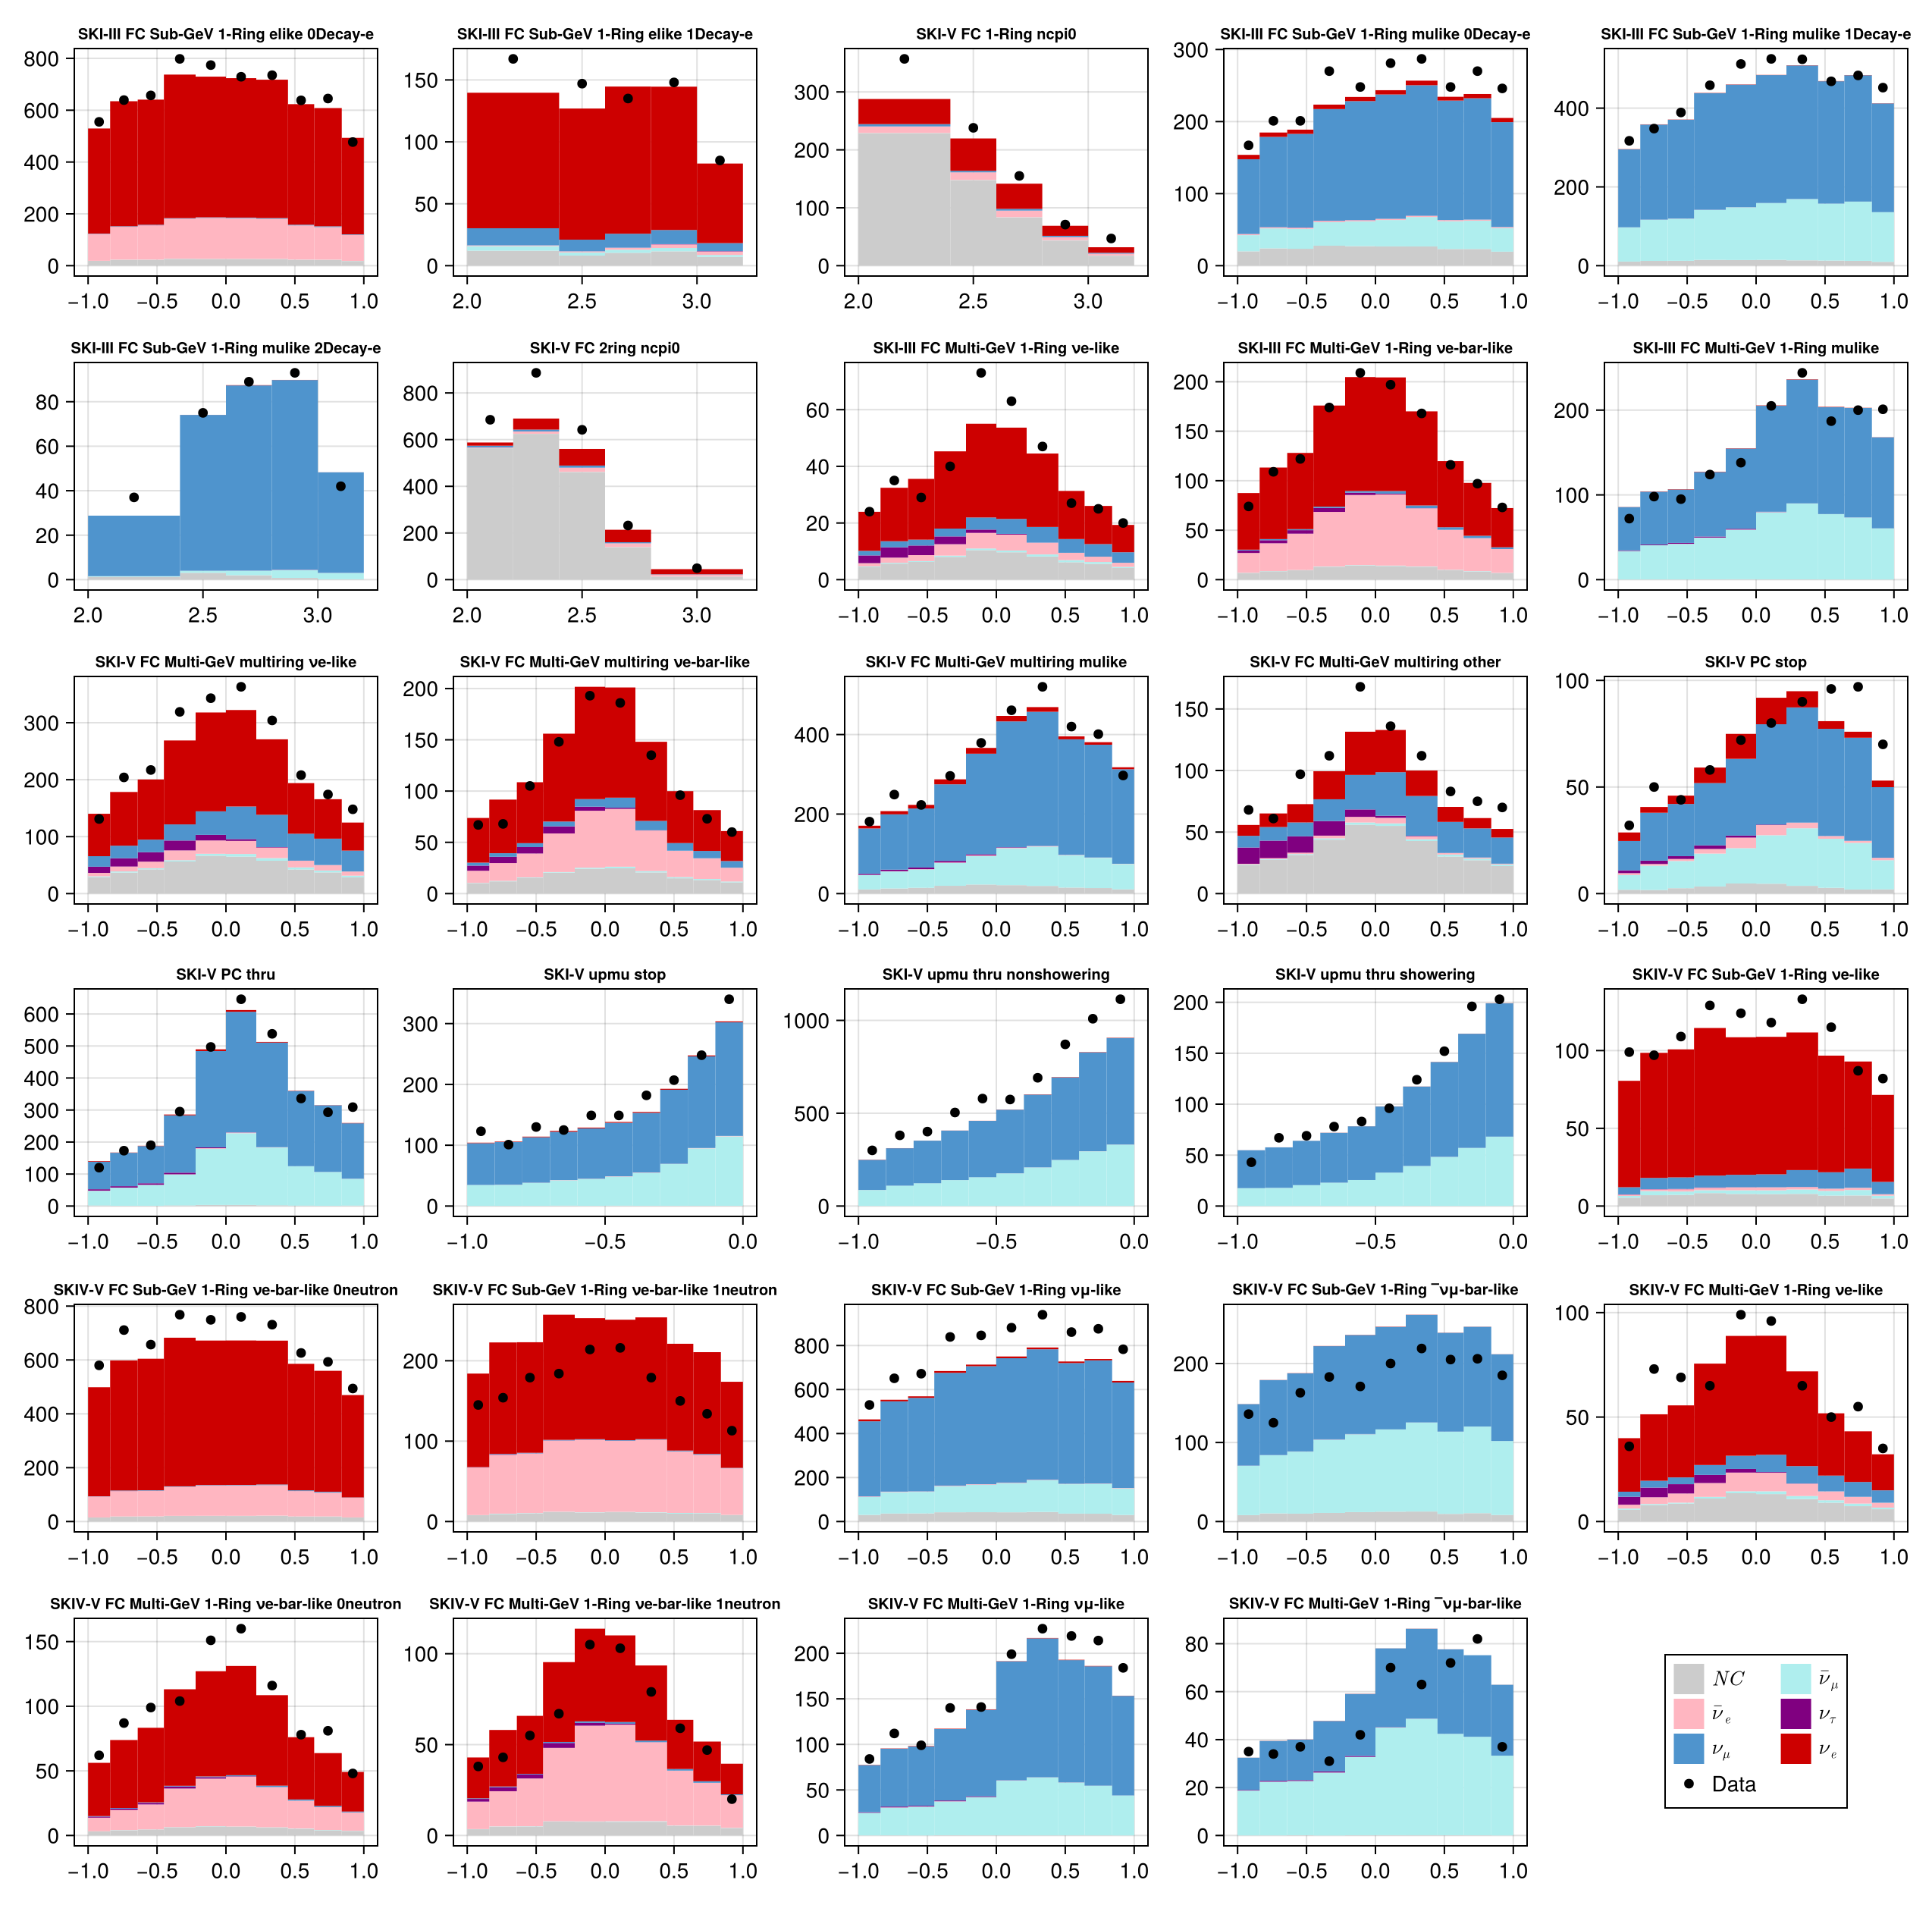

In [21]:
sk.plot(params)

In [22]:
using DensityInterface, BAT, MeasureBase

In [23]:
#assets = sk.assets
#@reset assets.R = NamedTuple(key=>Float64.(assets.R[key]) for key in keys(assets.R))

In [24]:
#@reset sk.assets = assets

In [47]:
likelihood = Newtrinos.generate_likelihood((;sk,));

In [ ]:
vars_to_scan = OrderedDict()
vars_to_scan[:θ₂₃] = 11
vars_to_scan[:Δm²₃₁] = 11

11

In [48]:
prior = distprod(;priors...)

NamedTupleDist((atm_flux_delta_spectral_index = Truncated(Normal{Float64}(μ=0.0, σ=0.1); lower=-0.3, upper=0.3), atm_flux_nuenumu_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_nunubar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_uphorizonzal_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), nc_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), nutau_cc_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976)))

In [49]:
bestfit = Newtrinos.find_mle(likelihood, prior, params)

(-3432.5863388570533, -3420.2830022569424, (atm_flux_delta_spectral_index = -0.0033968994040153746, atm_flux_nuenumu_sigma = 1.5559060258075994, atm_flux_nunubar_sigma = 2.999999999999953, atm_flux_uphorizonzal_sigma = -1.1740450726174139, nc_norm = 1.2203961247461992, nutau_cc_norm = 0.8356340178527234, Δm²₂₁ = 6.500000535397408e-5, Δm²₃₁ = 0.002445749739250691, δCP = 1.4397774443957565, θ₁₂ = 0.42053440356686445, θ₁₃ = 0.17653911710398398, θ₂₃ = 0.963562826073675))

In [41]:
e = mean(sk.forward_model(params)) 

sum((e .- sk.assets.observed).^2 ./ e)

2207.870545253426

In [50]:
e = mean(sk.forward_model(bestfit[3])) 

sum((e .- sk.assets.observed).^2 ./ e)

1638.5750716136013

In [51]:
bestfit[3]

(atm_flux_delta_spectral_index = -0.0033968994040153746, atm_flux_nuenumu_sigma = 1.5559060258075994, atm_flux_nunubar_sigma = 2.999999999999953, atm_flux_uphorizonzal_sigma = -1.1740450726174139, nc_norm = 1.2203961247461992, nutau_cc_norm = 0.8356340178527234, Δm²₂₁ = 6.500000535397408e-5, Δm²₃₁ = 0.002445749739250691, δCP = 1.4397774443957565, θ₁₂ = 0.42053440356686445, θ₁₃ = 0.17653911710398398, θ₂₃ = 0.963562826073675)

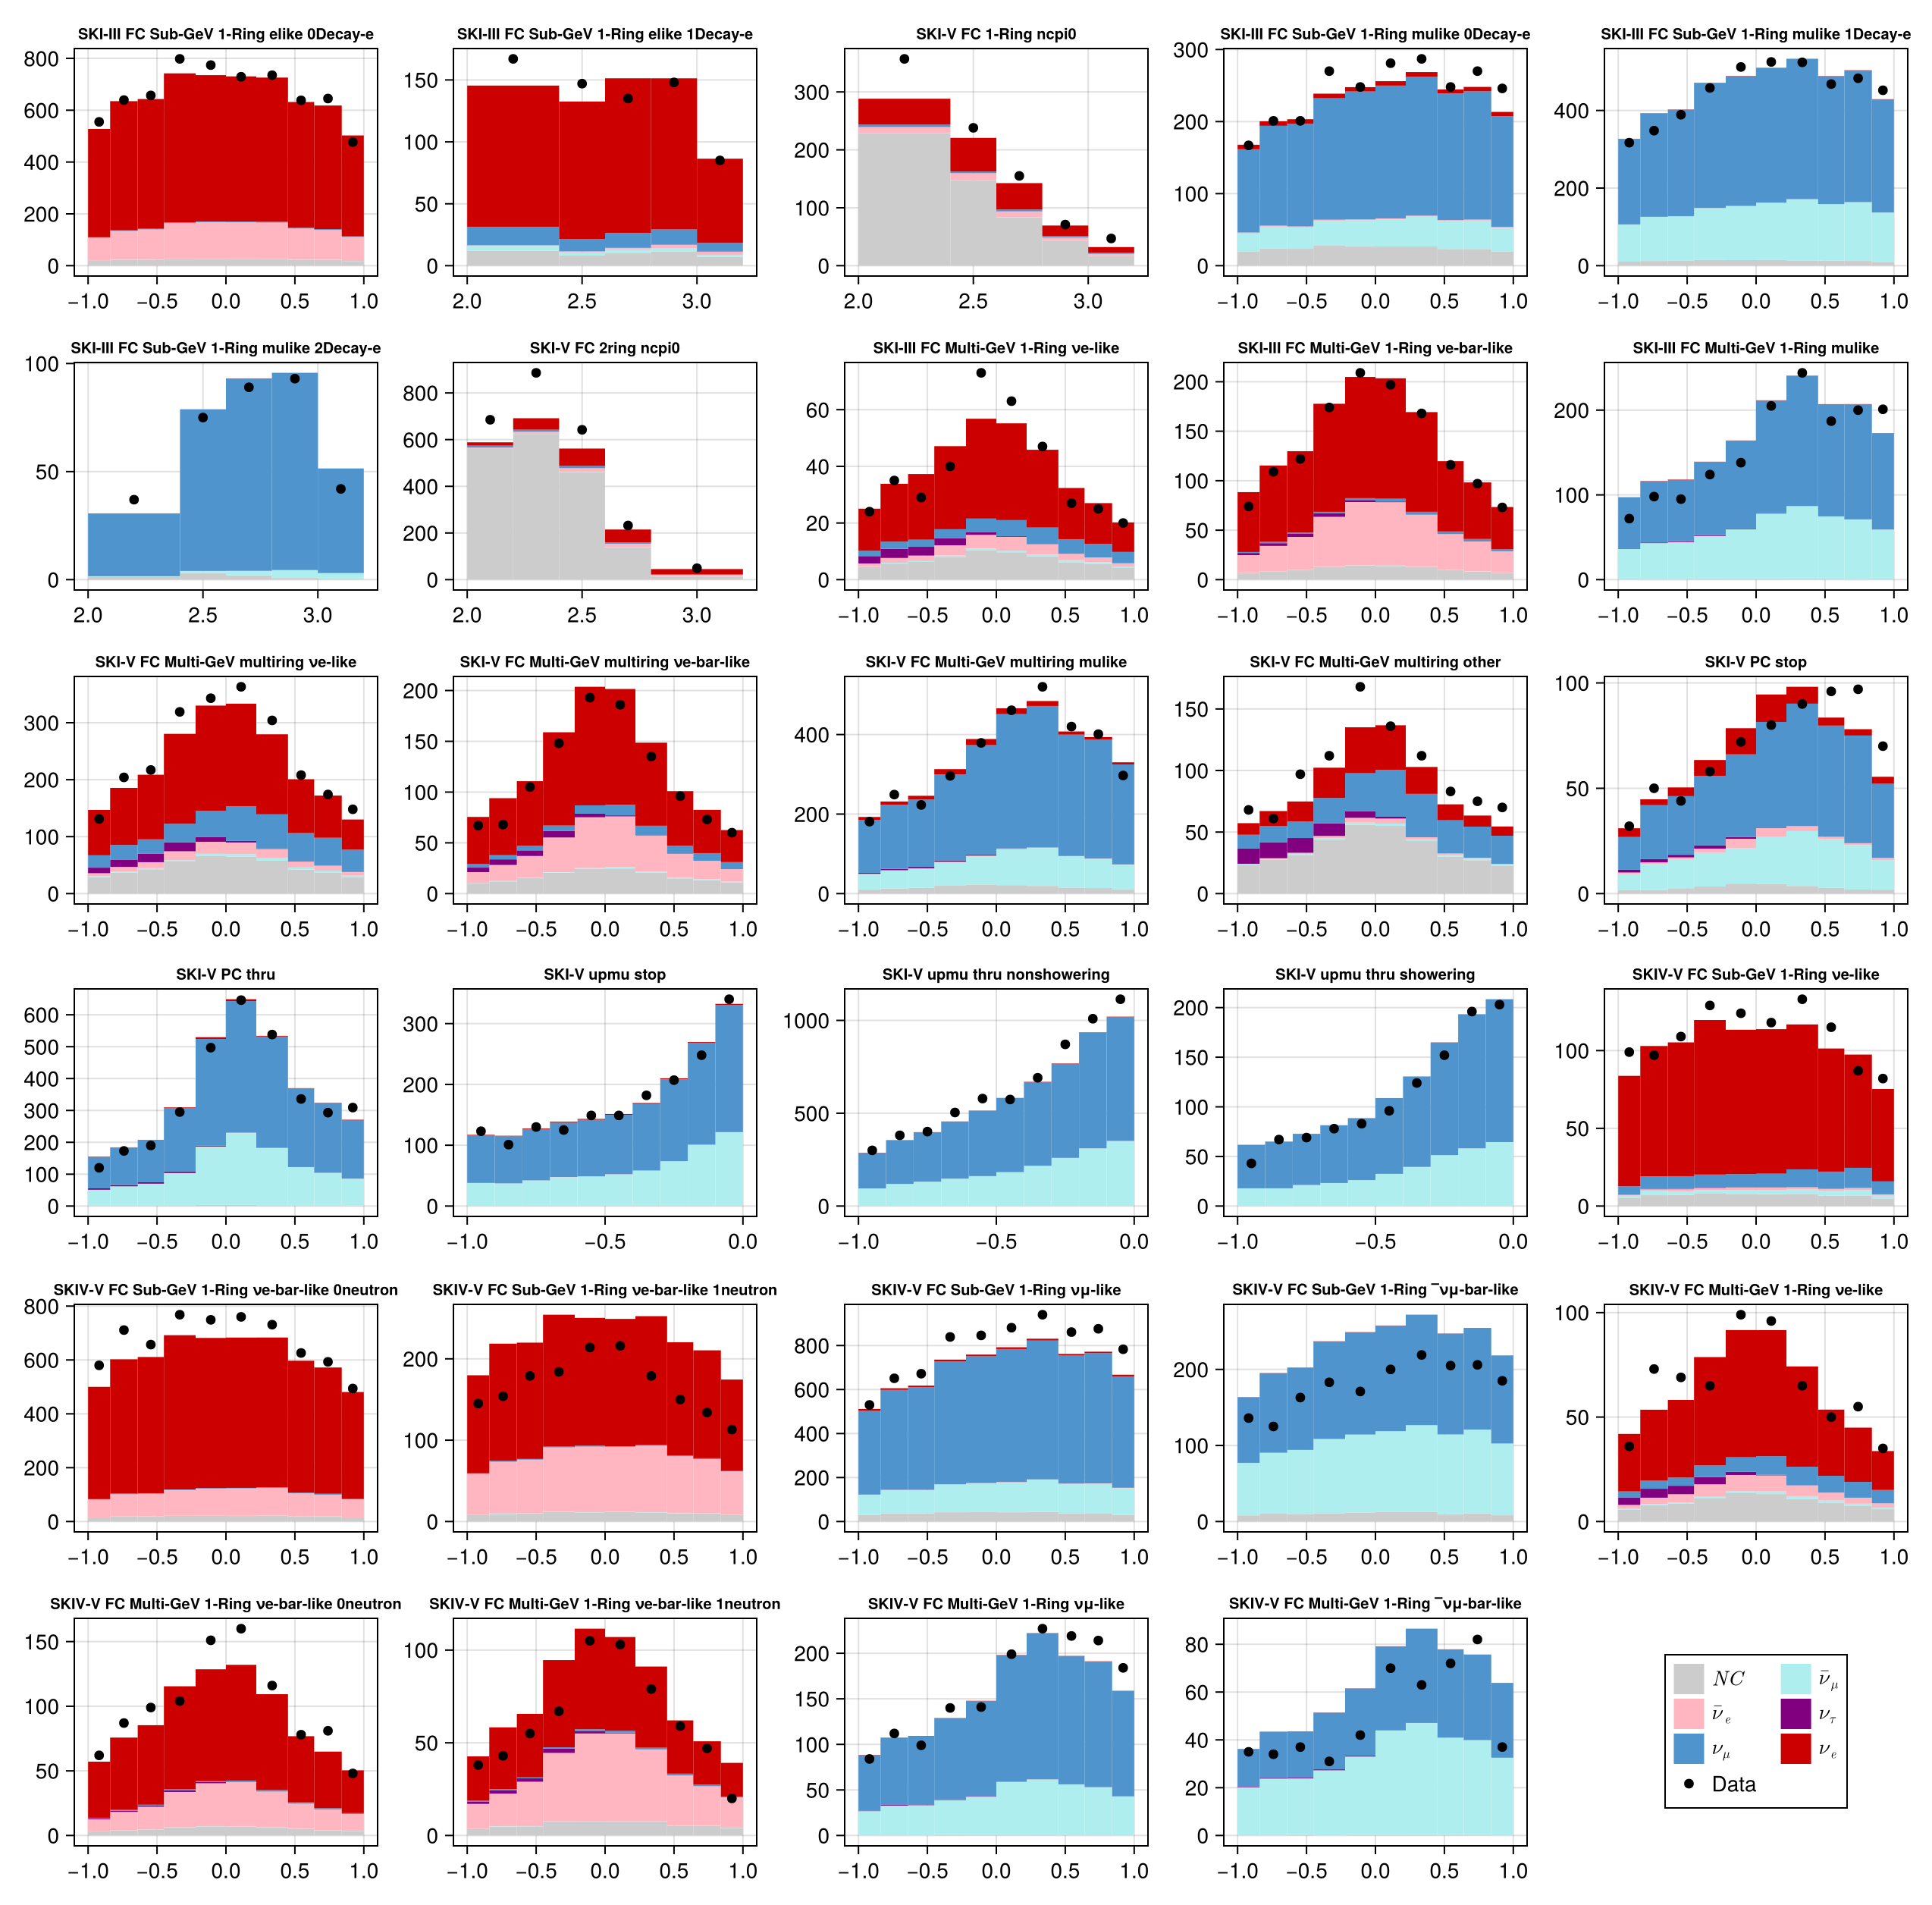

In [52]:
sk.plot(bestfit[3])

In [ ]:
result = Newtrinos.profile(likelihood, priors, vars_to_scan, params)

In [55]:
unique(sk.assets.bininfo.Sample)

29-element Vector{String}:
 "sk1-3_fc_subgev_1ring_elike_0decaye"
 "sk1-3_fc_subgev_1ring_elike_1decaye"
 "sk1-5_fc_1ring_ncpi0"
 "sk1-3_fc_subgev_1ring_mulike_0decaye"
 "sk1-3_fc_subgev_1ring_mulike_1decaye"
 "sk1-3_fc_subgev_1ring_mulike_2decaye"
 "sk1-5_fc_2ring_ncpi0"
 "sk1-3_fc_multigev_1ring_nuelike"
 "sk1-3_fc_multigev_1ring_nuebarlike"
 "sk1-3_fc_multigev_1ring_mulike"
 ⋮
 "sk4-5_fc_subgev_1ring_nuebarlike_0neutron"
 "sk4-5_fc_subgev_1ring_nuebarlike_1neutron"
 "sk4-5_fc_subgev_1ring_numulike"
 "sk4-5_fc_subgev_1ring_numubarlike"
 "sk4-5_fc_multigev_1ring_nuelike"
 "sk4-5_fc_multigev_1ring_nuebarlike_0neutron"
 "sk4-5_fc_multigev_1ring_nuebarlike_1neutron"
 "sk4-5_fc_multigev_1ring_numulike"
 "sk4-5_fc_multigev_1ring_numubarlike"

In [56]:
params

(atm_flux_delta_spectral_index = 0.0, atm_flux_nuenumu_sigma = 0.0, atm_flux_nunubar_sigma = 0.0, atm_flux_uphorizonzal_sigma = 0.0, nc_norm = 1.0, nutau_cc_norm = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [21]:
using ForwardDiff

In [80]:
logdensityof(likelihood, params)

-3706.137998665219

In [81]:
f(p) = logdensityof(likelihood, p)

f (generic function with 1 method)

In [82]:
gradient = ForwardDiff.gradient(f, params)

(atm_flux_delta_spectral_index = -10470.29304791424, atm_flux_nuenumu_sigma = 4.575152425935981, atm_flux_nunubar_sigma = 37.25828674774625, atm_flux_uphorizonzal_sigma = 24.610547327870503, nc_norm = 0.0, nutau_cc_norm = 0.0, Δm²₂₁ = -64255.722385013716, Δm²₃₁ = -146432.11453695575, δCP = 2.3162915142678306, θ₁₂ = -11.48226323763429, θ₁₃ = -93.35334641726556, θ₂₃ = 1096.4812441269785)

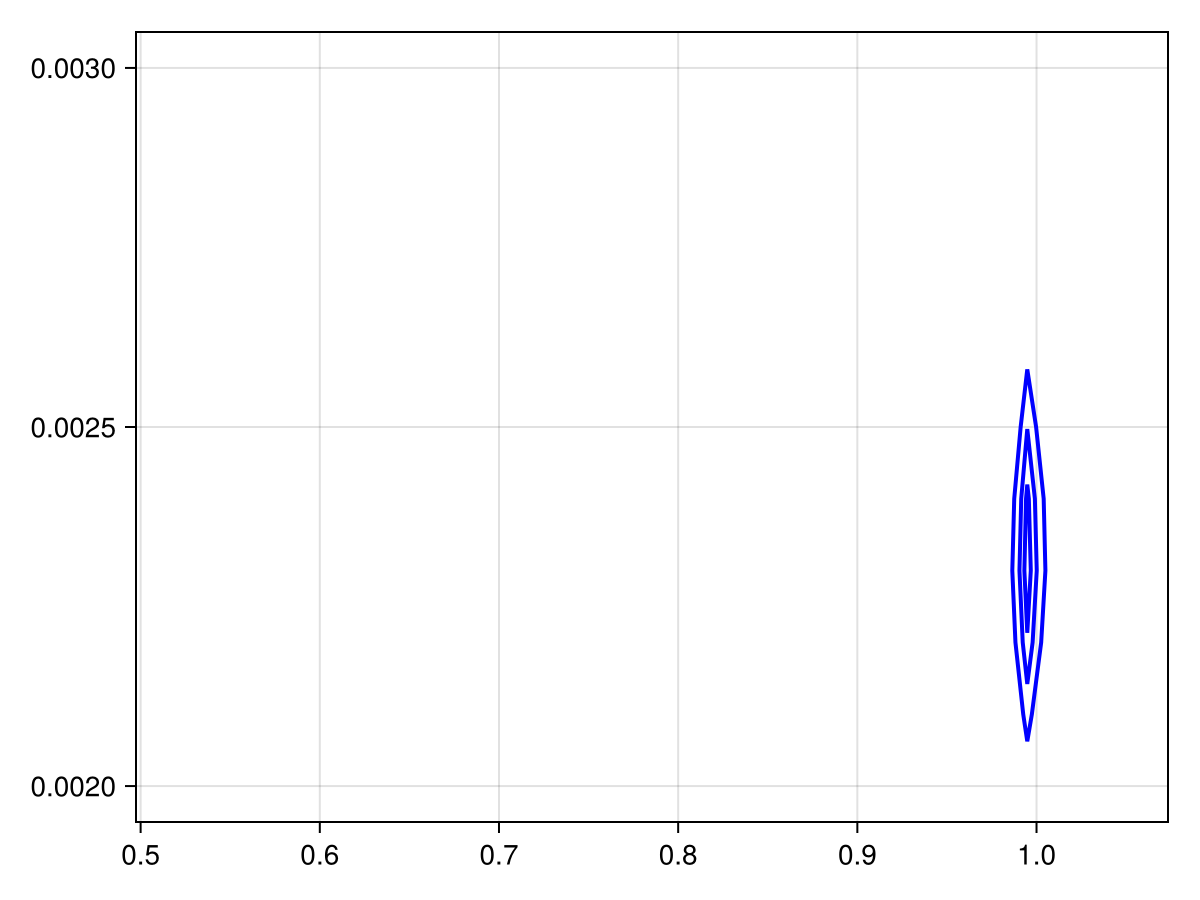

In [84]:
plot(result)

In [86]:
using FileIO

In [87]:
save("sk_atm_2023_profile_result.jld2", Dict("result"=>result))